<a href="https://colab.research.google.com/github/Pranayshukla0610/Data-Science-Projects/blob/main/End_to_End_Generative_AI_System_Avatar_Creation%2C_Face_Swap_%26_Image_Editing_using_Diffusion_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install diffusers transformers accelerate safetensors torch torchvision insightface opencv-python -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 762.2/762.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 42.6 MB/s eta 0:00:00


In [2]:
!pip install insightface

In [3]:
import torch
import cv2
from diffusers import StableDiffusionPipeline, StableDiffusionInpaintPipeline
from insightface.app import FaceAnalysis
from insightface.model_zoo import get_model
from google.colab.patches import cv2_imshow
from IPython.display import display
import numpy as np

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
model_id = 'runwayml/stable-diffusion-v1-5'
txt2img = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype = torch.float16
).to('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
prompt = """
portrait of a person, ultra detailed,
cinematic lighting, anime style avatar,
beautiful face, sharp eyes, high quality,
instagram profile picture style"""

  0%|          | 0/30 [00:00<?, ?it/s]

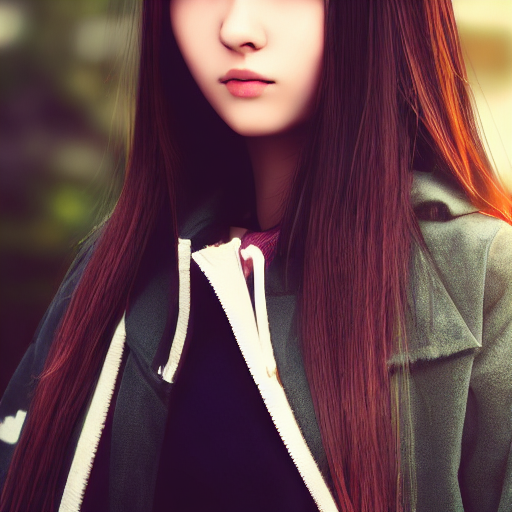

In [6]:
avatar = txt2img(
    prompt,
    num_inference_steps=30,
    guidance_scale=8.0
).images[0]

display(avatar)
avatar.save("avatar.png")

In [9]:
!rm -rf /root/.insightface/models/inswapper_128.onnx

In [27]:
from diffusers import StableDiffusionImg2ImgPipeline

img2img = StableDiffusionImg2ImgPipeline.from_pretrained(
    model_id,
    torch_dtype = torch.float16
).to('cuda')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
uploaded = files.upload()
init_image = cv2.imread("source.jpg")

Saving My Pic 3.jpg to My Pic 3.jpg


In [31]:
print(type(init_image))
print(init_image)

<class 'NoneType'>
None


In [34]:
print(init_image.shape if hasattr(init_image, "shape") else "No shape")

No shape


In [36]:
import cv2
init_image = cv2.imread("your_image_path.jpg")
print(init_image)

None


In [37]:
import cv2
from PIL import Image

path = "/content/My Pic 3.jpg"

init_image = cv2.imread(path)

if init_image is None:
    raise ValueError(f"Image not found at path: {path}")

init_image = cv2.cvtColor(init_image, cv2.COLOR_BGR2RGB)
init_image = Image.fromarray(init_image)

In [40]:


init_image = init_image.convert("RGB")

In [41]:
prompt = "anime style portrait, ultra detailed, studio lighting"

  0%|          | 0/37 [00:00<?, ?it/s]

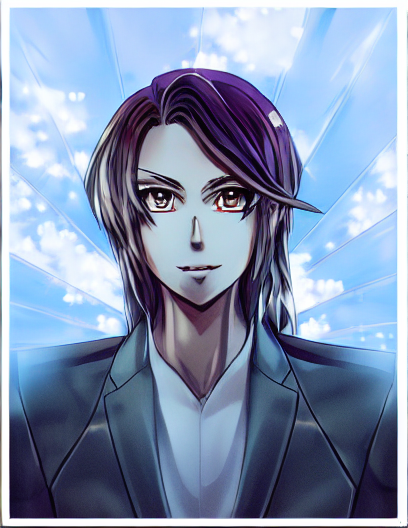

In [42]:
styled = img2img(
    prompt=prompt,
    image=init_image,
    strength=0.75,
    guidance_scale=8.0
).images[0]

display(styled)
styled.save("styled.png")

In [43]:
from diffusers import StableDiffusionInpaintPipeline

inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float16
).to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [44]:
uploaded = files.upload()

Saving 0ed58cccd51c4758e634d0b29e8cb0c2.jpg to 0ed58cccd51c4758e634d0b29e8cb0c2.jpg


In [46]:
from PIL import Image

image = Image.open("0ed58cccd51c4758e634d0b29e8cb0c2.jpg").convert("RGB")

In [49]:
from google.colab import files
files.upload()

Saving 0ed58cccd51c4758e634d0b29e8cb0c2.jpg to 0ed58cccd51c4758e634d0b29e8cb0c2 (1).jpg


{'0ed58cccd51c4758e634d0b29e8cb0c2 (1).jpg': b'\xff\xd8\xff\xdb\x00\xc5\x00\x04\x05\x05\t\x06\t\t\t\t\t\n\x08\t\x08\n\x0b\x0b\n\n\x0b\x0b\x0c\n\x0b\n\x0b\n\x0c\x0c\x0c\x0c\r\r\x0c\x0c\x0c\x0c\x0c\x0f\x0e\x0f\x0c\x0c\r\x0f\x0f\x0f\x0f\r\x0e\x11\x11\x11\x0e\x11\x10\x10\x11\x13\x11\x13\x11\x11\r\x01\x04\x06\x06\n\t\n\x0b\n\n\x0b\x0b\x0c\x0c\x0c\x0b\x0f\x10\x12\x12\x10\x0f\x12\x10\x11\x11\x11\x10\x12\x1e"\x1c\x11\x11\x1c"\x1e\x17j\x1a\x13\x1aj\x17\x1a\x1f\x0f\x0f\x1f\x1a*\x11\x1f\x11*<..<\x0f\x0f\x0f\x0f\x0ft\x02\x04\x04\x04\x08\x06\x08\x07\x08\x08\x07\x08\x06\x08\x06\x08\x08\x08\x07\x07\x08\x08\t\x07\x07\x07\x07\x07\t\n\t\x08\x08\x08\x08\t\n\t\x08\x08\x06\x08\x08\t\t\t\n\n\t\t\n\x08\t\x08\n\n\n\n\n\x0e\x10\x0e\x0e\x0ew\xff\xc2\x00\x11\x08\x03\x97\x02\xe0\x03\x01"\x00\x02\x11\x01\x03\x11\x02\xff\xc4\x00\xdc\x00\x00\x01\x05\x01\x01\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x03\x01\x02\x04\x05\x06\x00\x07\x08\t\x10\x00\x02\x02\x02\x02\x03\x00\x03\x01\x01\x01\x01\x00\x00\x00\x00\x01\x02\x03

In [50]:
import os
print(os.listdir())

['.config', '0ed58cccd51c4758e634d0b29e8cb0c2 (1).jpg', '0ed58cccd51c4758e634d0b29e8cb0c2.jpg', 'shah-rukh-khan-poster.avif', 'avatar.png', 'My Pic 3.jpg', 'styled.png', 'sample_data']


In [51]:
import glob

print(glob.glob("*.jpg"))
print(glob.glob("*.png"))

['0ed58cccd51c4758e634d0b29e8cb0c2 (1).jpg', '0ed58cccd51c4758e634d0b29e8cb0c2.jpg', 'My Pic 3.jpg']
['avatar.png', 'styled.png']


In [54]:
image = Image.open("0ed58cccd51c4758e634d0b29e8cb0c2.jpg").convert("RGB")
mask = Image.open("0ed58cccd51c4758e634d0b29e8cb0c2.jpg").convert("RGB")

  0%|          | 0/50 [00:00<?, ?it/s]

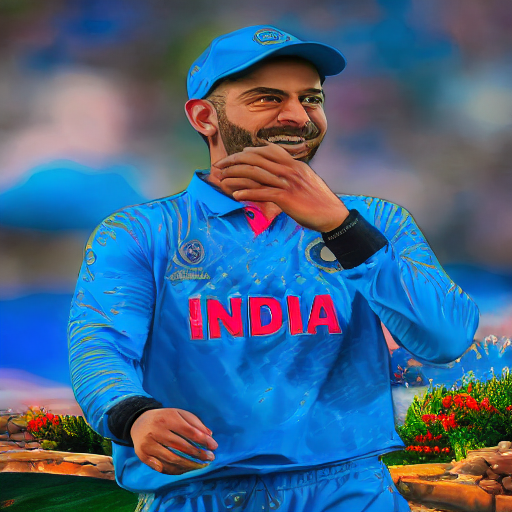

In [55]:
result = inpaint(
    prompt="clean background, realistic",
    image=image,
    mask_image=mask
).images[0]

display(result)
result.save("inpaint.png")